In [1]:
# standard library
import sys
from pathlib import Path

# third-party
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score

# project-local
project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

from src.evaluation import evaluate_classification_model, check_overfitting

# Diabetes prediction - Train (diabetes prediction)

For this smaller dataset, only Logistic Regression and Random Forest are used. More complex ensemble methods are reserved for the larger BRFSS dataset.

## Algorithm Selection Rationale

**Logistic Regression** is used as the interpretable baseline. Its coefficients can be directly checked against clinical expectations (e.g. higher blood pressure or cholesterol should increase predicted risk), providing a sanity check beyond raw performance metrics, and it is fast to train and tune, making it a natural starting point before more complex models.

**Random Forest** is included because several of the strongest predictors in this data are known to behave as clinical thresholds rather than linear relationships (e.g. HbA1c $\geq$ 6.5% or blood pressure classifications, as discussed in the EDA notebook), which a linear model can only approximate through a single coefficient per feature. Random Forest can capture such threshold effects and feature interactions natively through its tree-based splits, and also provides a second, independent feature importance ranking to cross-check against the Logistic Regression coefficients.

## Load Data

In [2]:
X_train = pd.read_csv("../../data/processed/diabetes_data_train.csv")
X_test = pd.read_csv("../../data/processed/diabetes_data_test.csv")

In [3]:
y_train = pd.read_csv("../../data/processed/diabetes_data_y_train.csv").squeeze()
y_test = pd.read_csv("../../data/processed/diabetes_data_y_test.csv").squeeze()

## Cross-Validation Strategy

A `StratifiedKFold` is defined explicitly, consistent with the BRFSS notebook, so folds are shuffled reproducibly and class balance (diabetes ~8.8% positive) is preserved in each fold.

In [4]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Logistic Regression

### Regularization

`C` controls the inverse strength of L2/L1 regularization. Both `lbfgs` (L2 only) and `saga` (L1 or L2) solvers are tested, split into two grid dictionaries to avoid requesting unsupported solver/penalty combinations.

### Hyperparameter Tuning

In [5]:
# Initialize logistic regression with balanced class weights
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

# Define hyperparameter grid for solver, penalty, and regularization strength (C)
param_grid = [
    {"solver": ["lbfgs"], "penalty": ["l2"], "C": [0.01, 0.1, 1, 10, 100]},
    {"solver": ["saga"], "penalty": ["l1", "l2"], "C": [0.01, 0.1, 1, 10, 100]}
]

# Set up GridSearch to find the best combination based on ROC-AUC
grid_search_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [6]:
grid_search_lr.fit(X_train, y_train)
print(f"Best params: {grid_search_lr.best_params_}")
print(f"Best CV ROC-AUC: {grid_search_lr.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.9624


### Prediction

In [7]:
best_lr = grid_search_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_pred_proba_lr = best_lr.predict_proba(X_test)[:, 1]

### Evaluation

=== Model Evaluation: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     17530
           1       0.43      0.88      0.57      1696

    accuracy                           0.89     19226
   macro avg       0.71      0.88      0.75     19226
weighted avg       0.94      0.89      0.90     19226

F1 (positive class): 0.5735
PR-AUC: 0.8120


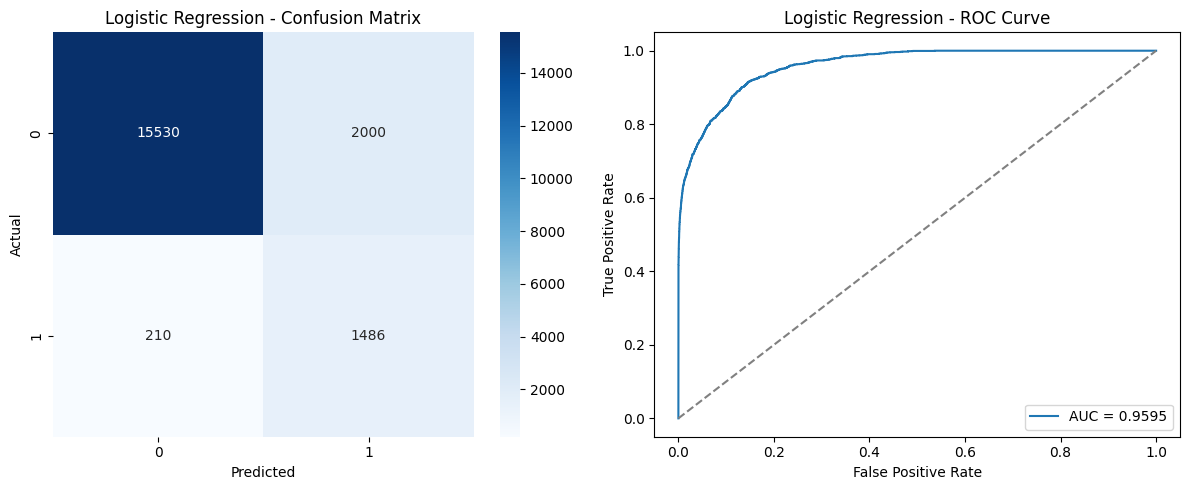

In [8]:
evaluate_classification_model(y_test, y_pred_lr, y_pred_proba_lr, model_name="Logistic Regression")

In [9]:
check_overfitting(best_lr, X_train, y_train, X_test, y_test, model_name="Logistic Regression")

=== Overfitting Check: Logistic Regression ===
Train ROC-AUC: 0.9626
Test ROC-AUC:  0.9595
Gap:           0.0030
Gap is small - no strong indication of overfitting.


Visually, the confusion matrix is dominated by the true-negative cell (15530), with a modest false-positive block (2000) and a much smaller false-negative cell (210) - the model rarely misses a diabetic case outright, consistent with the high recall. The ROC curve rises very steeply at low false-positive rates and hugs the top-left corner for most of its length before flattening near TPR = 1, visibly much closer to the ideal corner than the BRFSS Logistic Regression ROC curve.

This translates into recall 0.88 and precision 0.43 on the diabetic class (F1 = 0.57), with ROC-AUC = 0.9595 and PR-AUC = 0.8120 - both far higher than the equivalent Logistic Regression numbers on the BRFSS dataset (ROC-AUC 0.818, PR-AUC 0.428). The gap makes sense: this dataset includes clinically direct lab measurements (HbA1c, blood glucose), which carry far more diagnostic signal than the lifestyle/survey-based BRFSS features.

### Feature Importance (Coefficients)

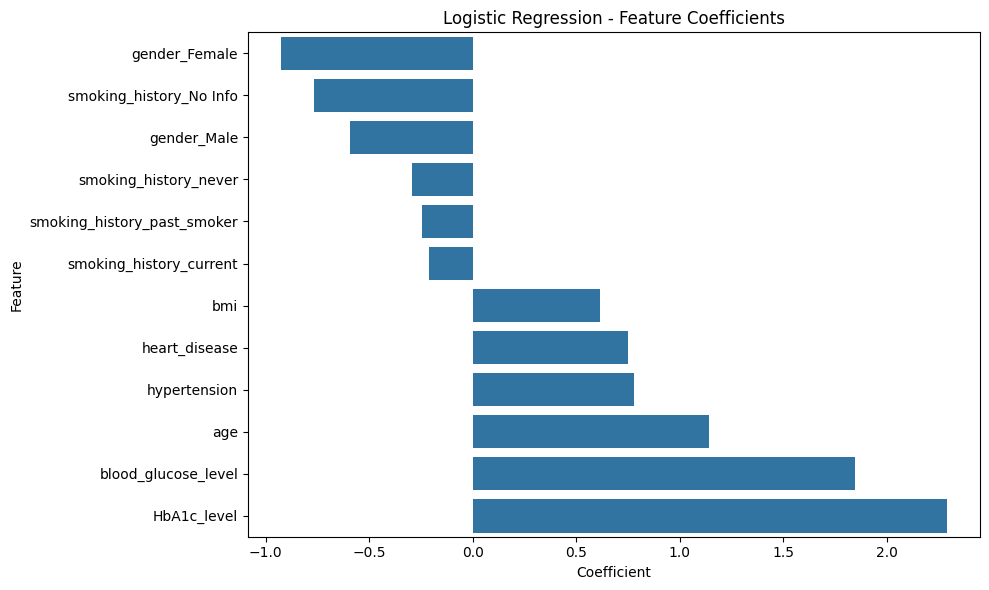

In [10]:
# Extract coefficients and map them to feature names
coefficients = best_lr.coef_[0]
feature_names = X_train.columns

# Create a DataFrame to store and sort feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values(by="Absolute_Coefficient", ascending=False)

# Visualize feature coefficients as a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=importance_df.sort_values(by="Coefficient"))
plt.title("Logistic Regression - Feature Coefficients")
plt.tight_layout()

plt.show()

Unlike the BRFSS coefficient plot, where a single feature (`chol_checked_recently`) towered over the rest, here the two largest bars - `HbA1c_level` and `blood_glucose_level` - are close in magnitude to each other, forming a clear top pair rather than one outlier. `age` and the two comorbidity flags (`hypertension`, `heart_disease`) form a distinct second tier of moderate positive coefficients, while `bmi` is positive but noticeably smaller.

The negative coefficients are almost entirely categorical encodings of `gender` and `smoking_history`, with `gender_Female` showing the strongest negative association - these act more as baseline/reference-category adjustments than genuine protective effects, and should not be over-interpreted causally.

### Save Model

In [11]:
models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_lr, models_dir / "logreg_diabetes_model.pkl")
print("Logistic Regression model saved.")

Logistic Regression model saved.


## Random Forest

### Regularization

`max_depth` and `min_samples_split` constrain tree complexity, serving an analogous role to `C` in Logistic Regression.

### Hyperparameter Tuning

In [12]:
# Initialize Random Forest with balanced class weights
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1)

# Define hyperparameter grid to tune forest size and tree complexity
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

# Run GridSearch to optimize model performance via ROC-AUC
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [13]:
grid_search_rf.fit(X_train, y_train)
print(f"Best params: {grid_search_rf.best_params_}")
print(f"Best CV ROC-AUC: {grid_search_rf.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Best CV ROC-AUC: 0.9760


### Prediction

In [14]:
best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

### Evaluation

=== Model Evaluation: Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.90      0.94     17530
           1       0.46      0.90      0.61      1696

    accuracy                           0.90     19226
   macro avg       0.73      0.90      0.78     19226
weighted avg       0.94      0.90      0.91     19226

F1 (positive class): 0.6129
PR-AUC: 0.8757


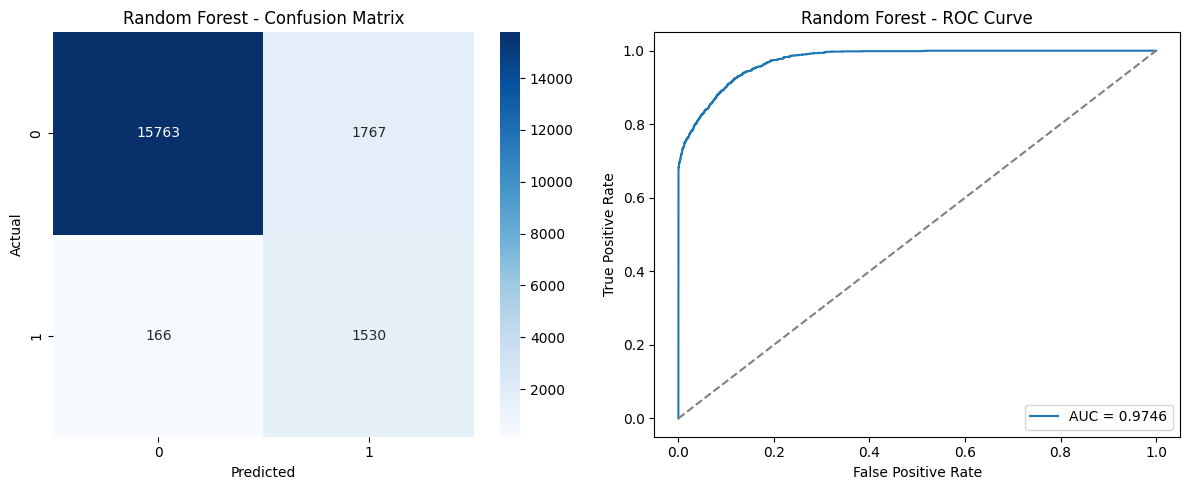

In [15]:
evaluate_classification_model(y_test, y_pred_rf, y_pred_proba_rf, model_name="Random Forest")

In [16]:
check_overfitting(best_rf, X_train, y_train, X_test, y_test, model_name="Random Forest")

=== Overfitting Check: Random Forest ===
Train ROC-AUC: 0.9793
Test ROC-AUC:  0.9746
Gap:           0.0048
Gap is small - no strong indication of overfitting.


The confusion matrix shows an even smaller false-negative count (166) and false-positive count (1,767) than Logistic Regression, and the ROC curve sits marginally above LR's for the entire low-FPR range, reaching almost TPR = 0.95 within the first 0.1 of FPR.

Random Forest improves on every metric here: recall 0.90, precision 0.46, F1 = 0.61, ROC-AUC = 0.9746, PR-AUC = 0.8757. The margin over Logistic Regression (+0.015 ROC-AUC) is larger than the equivalent gap on BRFSS (+0.004), suggesting the non-linear interactions Random Forest can capture matter more when the strongest predictors (HbA1c, glucose) are themselves noisy lab readings rather than clean survey categories.

### Feature Importance

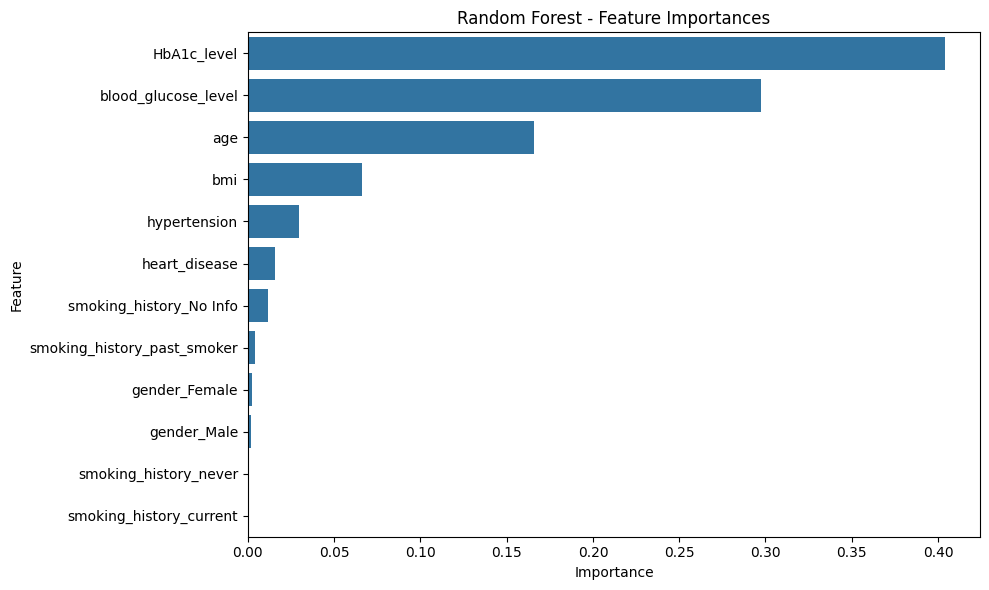

In [17]:
# Extract feature importance values from the trained model
importances = best_rf.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easy sorting and visualization
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot feature importance using a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Random Forest - Feature Importances")
plt.tight_layout()

plt.show()

The importance chart is dominated by the same two features as the Logistic Regression coefficients - `HbA1c_level` (~0.40) and `blood_glucose_level` (~0.30) - together accounting for roughly 70% of total importance, followed by a much smaller `age` bar (~0.17) and an even smaller `bmi` bar (~0.065). Every remaining feature (`hypertension`, `heart_disease`, `smoking_history` and `gender` dummies) contributes less than 0.03 importance each, forming a long, flat tail.

This is a much steeper drop-off than the BRFSS Random Forest importances, where the top three features were comparatively close in magnitude - here, two lab measurements carry almost all of the model's predictive weight, with demographic and lifestyle features adding only marginal value on top.

### Save Model

In [18]:
joblib.dump(best_rf, models_dir / "rf_diabetes_model.pkl")
print("Random Forest model saved.")

Random Forest model saved.


## Final Comparison (Diabetes Prediction Dataset)

In [19]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_pred_proba_lr),
        average_precision_score(y_test, y_pred_proba_rf)
    ]
})

print(comparison.sort_values(by="ROC-AUC", ascending=False))

                 Model   ROC-AUC        F1    PR-AUC
1        Random Forest  0.974574  0.612858  0.875699
0  Logistic Regression  0.959523  0.573524  0.812034


Final Comparison (Diabetes Prediction Dataset)

| Model | ROC-AUC | F1 | PR-AUC |
|---|---|---|---|
| Random Forest | 0.9746 | 0.6129 | 0.8757 |
| Logistic Regression | 0.9595 | 0.5735 | 0.8120 |

Key observations:

Unlike the BRFSS dataset, where all four models clustered within 0.007 ROC-AUC of each other, here Random Forest opens up a much larger gap over Logistic Regression (+0.015 ROC-AUC, +0.039 F1, +0.064 PR-AUC) - a sign that non-linear feature interactions matter more once the two dominant predictors (`HbA1c_level`, `blood_glucose_level`) are noisy, continuous lab readings rather than clean survey categories.

Both models perform far above their BRFSS counterparts across every metric (ROC-AUC 0.96-0.97 vs. 0.82-0.83, PR-AUC 0.81-0.88 vs. 0.43-0.46), confirming that direct clinical measurements carry substantially more diagnostic signal than the lifestyle/demographic features available in BRFSS - unsurprising, since BRFSS is a self-reported survey while this dataset includes lab-derived values.

The overfitting checks (train vs. test ROC-AUC gap) were small for both models (0.0030 for Logistic Regression, 0.0048 for Random Forest), indicating neither model memorized the training data despite the much higher absolute performance - the gains here come from genuinely more informative features, not overfitting.

Given the clear and consistent advantage of Random Forest on every metric, and since no ensemble methods were used on this smaller dataset (see intro), Random Forest is the natural choice as the final model for this dataset - it strictly dominates Logistic Regression here, unlike on BRFSS where the choice between models was closer to a trade-off between simplicity and marginal performance gains.